In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
font_candidates = ['AppleGothic', 'Malgun Gothic', 'NanumGothic']
available_fonts = {f.name for f in fm.fontManager.ttflist}
selected_font = next((font for font in font_candidates if font in available_fonts), None)
if selected_font:
    plt.rcParams['font.family'] = selected_font
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 4)
print('selected_font:', selected_font)


selected_font: AppleGothic


## 6개 스테이션 통합 실행 Baseline

이 노트북은 6개 스테이션을 한 번에 처리하면서 `K=4, 군집당 대표 월 2개, Model Compare` 시나리오 폴더에 함께 두기 위한 통합 baseline 파일입니다.

### 포함 범위
- 각 스테이션 `2024 train / valid`, `2025 test` 데이터 구성
- 개별 스테이션 `RandomForest` baseline 학습 및 점수
- 6개 스테이션 통합 `RandomForest` baseline 학습 및 점수
- 개별 모델 vs 통합 모델 비교 표와 그래프

### 비고
- 이 통합 파일은 군집 기반 대표 월 선택이 아니라, 6개 스테이션 전체 baseline 비교용입니다.
- 단일 스테이션 세부 실험은 같은 폴더 안의 개별 노트북을 사용합니다.


In [2]:
station_info = {
    'ST-481': '상현',
    'ST-2425': '다원',
    'ST-1331': '찬솔',
    'ST-454': '신영',
    'ST-453': '혜전',
    'ST-2264': '광태',
}
station_ids = list(station_info.keys())
base_path = Path('../../../../Data/sort_data/preprocessed_6station')
feature_cols = [
    '온도', '습도', '강수량', 'snow_flag', 'is_restingday',
    'month_sin', 'month_cos', 'hour_sin', 'hour_cos'
]
static_cols = [
    '위도', '경도', 'residential_index', 'business_index',
    'tourism_index', 'transit_index', 'commute_in_index', 'commute_out_index'
]
target_col = 'total_flow'
rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [8, None],
    'min_samples_leaf': [1, 3, 5],
}
search_cv = TimeSeriesSplit(n_splits=4)
print('station_ids:', station_ids)
print('target_col:', target_col)


station_ids: ['ST-481', 'ST-2425', 'ST-1331', 'ST-454', 'ST-453', 'ST-2264']
target_col: total_flow


In [3]:
def load_station_csv(station_id, year_suffix=''):
    path = base_path / f'{station_id}{year_suffix}.csv'
    df = pd.read_csv(path)
    df = df.loc[~df['종료_대여소_ID'].astype(str).str.strip().str.upper().eq('X')].copy()
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
    else:
        df['기준_날짜'] = pd.to_datetime(df['기준_날짜'])
        df['timestamp'] = df['기준_날짜'] + pd.to_timedelta(df['시간대'], unit='h')
    return df
def make_station_hourly(raw_df, feature_columns, add_static=True):
    agg_map = {
        'inflow': ('station_role', lambda s: ((s == 'end') | (s == 'both')).sum()),
        'outflow': ('station_role', lambda s: ((s == 'start') | (s == 'both')).sum()),
    }
    for col in feature_columns:
        agg_map[col] = (col, 'first')
    if add_static:
        for col in static_cols:
            if col in raw_df.columns:
                agg_map[col] = (col, 'first')
    if 'station_id' in raw_df.columns:
        agg_map['station_id'] = ('station_id', 'first')
    hourly_df = raw_df.sort_values('timestamp').groupby('timestamp').agg(**agg_map)
    full_idx = pd.date_range(hourly_df.index.min(), hourly_df.index.max(), freq='h')
    hourly_df = hourly_df.reindex(full_idx)
    hourly_df.index.name = 'timestamp'
    hourly_df[['inflow', 'outflow']] = hourly_df[['inflow', 'outflow']].fillna(0)
    fill_forward_cols = [c for c in hourly_df.columns if c not in ['inflow', 'outflow']]
    for col in fill_forward_cols:
        hourly_df[col] = hourly_df[col].ffill().bfill()
    hourly_df = hourly_df.reset_index()
    hourly_df['total_flow'] = hourly_df['inflow'] + hourly_df['outflow']
    hourly_df['net_flow'] = hourly_df['inflow'] - hourly_df['outflow']
    return hourly_df
def split_train_valid(hourly_df, train_ratio=0.7):
    split_idx = int(len(hourly_df) * train_ratio)
    train_df = hourly_df.iloc[:split_idx].copy()
    valid_df = hourly_df.iloc[split_idx:].copy()
    return train_df, valid_df
def score_regression(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
    }


## 개별 스테이션 데이터 준비

각 스테이션마다:
- `2024` 데이터를 시간대별 `total_flow`로 집계
- `2025` 데이터를 외부 테스트용 시간대 데이터로 집계
- `2024` 내부를 `train 70% / valid 30%`로 분리


In [4]:
station_datasets = {}
station_static_map = {}
station_split_summary = []
for station_id in station_ids:
    train_raw = load_station_csv(station_id, '')
    test_raw = load_station_csv(station_id, '_2025')
    train_hourly = make_station_hourly(train_raw, feature_cols, add_static=True)
    station_static_map[station_id] = {col: train_hourly[col].iloc[0] for col in static_cols if col in train_hourly.columns}
    test_hourly = make_station_hourly(test_raw, feature_cols, add_static=True)
    for col, value in station_static_map[station_id].items():
        if col not in test_hourly.columns:
            test_hourly[col] = value
    train_df, valid_df = split_train_valid(train_hourly, train_ratio=0.7)
    station_datasets[station_id] = {
        'train': train_df,
        'valid': valid_df,
        'test': test_hourly,
    }
    station_split_summary.append({
        'station_id': station_id,
        'station_name': station_info[station_id],
        'train_rows': len(train_df),
        'valid_rows': len(valid_df),
        'test_rows': len(test_hourly),
        'train_start': train_df['timestamp'].min(),
        'train_end': train_df['timestamp'].max(),
        'test_start': test_hourly['timestamp'].min(),
        'test_end': test_hourly['timestamp'].max(),
    })
station_split_summary = pd.DataFrame(station_split_summary)
display(station_split_summary)


,station_id,station_name,train_rows,valid_rows,test_rows,train_start,train_end,test_start,test_end
0,ST-481,상현,6148,2636,8567,2024-01-01 00:00:00,2024-09-13 03:00:00,2025-01-09 00:00:00,2025-12-31 22:00:00
1,ST-2425,다원,6147,2635,8567,2024-01-01 01:00:00,2024-09-13 03:00:00,2025-01-09 01:00:00,2025-12-31 23:00:00
2,ST-1331,찬솔,6148,2636,8568,2024-01-01 00:00:00,2024-09-13 03:00:00,2025-01-09 00:00:00,2025-12-31 23:00:00
3,ST-454,신영,6148,2636,8568,2024-01-01 00:00:00,2024-09-13 03:00:00,2025-01-09 00:00:00,2025-12-31 23:00:00
4,ST-453,혜전,6148,2635,8567,2024-01-01 01:00:00,2024-09-13 04:00:00,2025-01-09 00:00:00,2025-12-31 22:00:00
5,ST-2264,광태,6148,2636,8568,2024-01-01 00:00:00,2024-09-13 03:00:00,2025-01-09 00:00:00,2025-12-31 23:00:00


## 타깃 점검
이 셀은 6개 스테이션 전체 기준으로 `inflow`, `outflow`, `total_flow`, `net_flow` 타깃을 함께 확인하기 위한 섹션입니다.
- `total_flow = inflow + outflow`
- `net_flow = inflow - outflow`

통합 파일에서도 `net_flow` 분포를 같이 보면 스테이션별 순유입/순유출 편향을 빠르게 확인할 수 있습니다.


6개 스테이션 전체 타깃 기술통계


,count,mean,std,min,25%,50%,75%,max
inflow,36887.0,5.179440,5.863605,0.0,0.0,4.0,8.0,55.0
outflow,36887.0,5.333586,6.043119,0.0,0.0,4.0,8.0,57.0
total_flow,36887.0,10.513026,10.552140,0.0,2.0,8.0,15.0,83.0
net_flow,36887.0,-0.154146,5.518571,-42.0,-2.0,0.0,2.0,44.0


스테이션별 평균 타깃


,station_id,inflow,outflow,total_flow,net_flow
0,ST-1331,4.5340,4.9675,9.5015,-0.4335
1,ST-2264,8.7315,8.5568,17.2882,0.1747
2,ST-2425,2.0716,2.6592,4.7308,-0.5876
3,ST-453,5.9117,5.5639,11.4756,0.3478
4,ST-454,5.7214,5.9997,11.7210,-0.2783
5,ST-481,4.1061,4.2541,8.3601,-0.1480


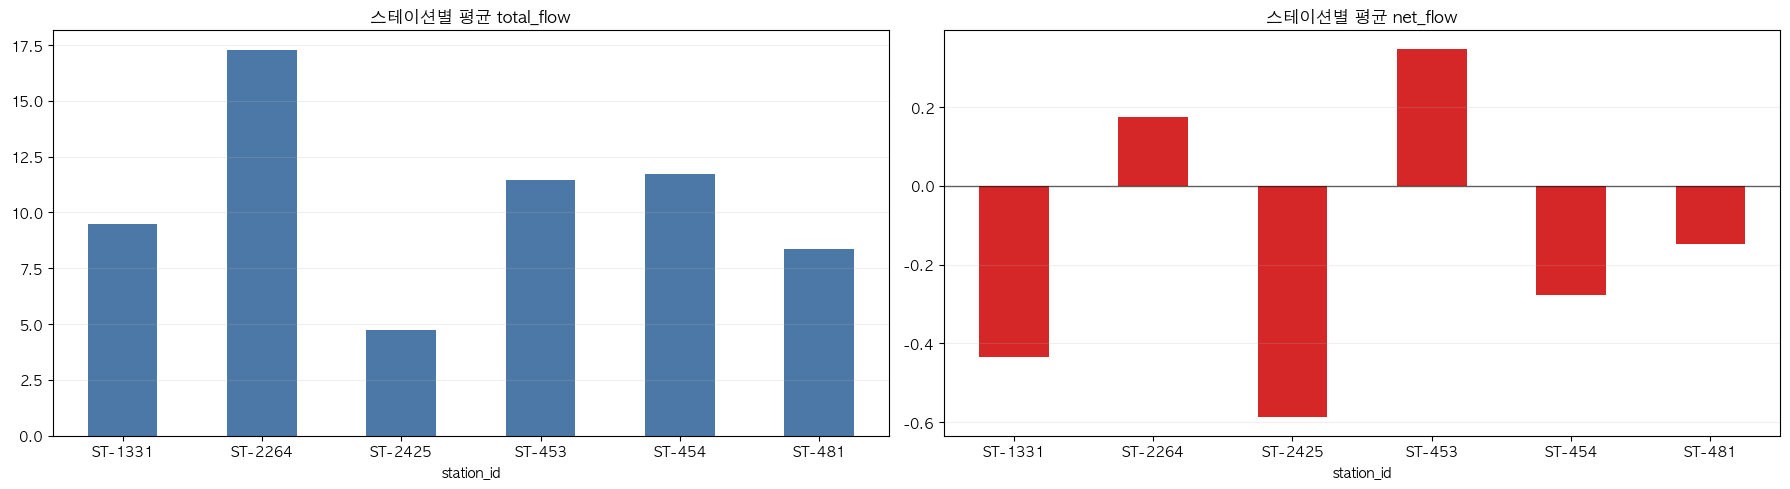

In [5]:
combined_target_view = pd.concat([
    station_datasets[s]['train'][['station_id', 'timestamp', 'inflow', 'outflow', 'total_flow', 'net_flow']]
    for s in station_ids
], ignore_index=True)

print('6개 스테이션 전체 타깃 기술통계')
display(combined_target_view[['inflow', 'outflow', 'total_flow', 'net_flow']].describe().T)

station_target_summary = (
    combined_target_view.groupby('station_id')[['inflow', 'outflow', 'total_flow', 'net_flow']]
    .mean()
    .reset_index()
)
print('스테이션별 평균 타깃')
display(station_target_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
station_target_summary.set_index('station_id')['total_flow'].plot(kind='bar', ax=axes[0], color='#4C78A8')
axes[0].set_title('스테이션별 평균 total_flow')
axes[0].grid(axis='y', alpha=0.2)
axes[0].tick_params(axis='x', rotation=0)

station_target_summary.set_index('station_id')['net_flow'].plot(kind='bar', ax=axes[1], color='#D62728')
axes[1].axhline(0, color='black', linewidth=1, alpha=0.6)
axes[1].set_title('스테이션별 평균 net_flow')
axes[1].grid(axis='y', alpha=0.2)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## 개별 스테이션 RandomForest 학습 및 점수

각 스테이션별로 `GridSearchCV`를 통해 `RandomForest` 최적 파라미터를 찾고,
같은 스테이션의 `valid`와 `2025 test` 점수를 계산합니다.


In [6]:
station_model_results = []
station_best_models = {}
for station_id in station_ids:
    train_df = station_datasets[station_id]['train']
    valid_df = station_datasets[station_id]['valid']
    test_df = station_datasets[station_id]['test']
    search = GridSearchCV(
        estimator=RandomForestRegressor(random_state=42, n_jobs=1),
        param_grid=rf_param_grid,
        scoring='r2',
        cv=search_cv,
        n_jobs=1,
    )
    search.fit(train_df[feature_cols], train_df[target_col])
    best_model = search.best_estimator_
    pred_train = best_model.predict(train_df[feature_cols])
    pred_valid = best_model.predict(valid_df[feature_cols])
    pred_test = best_model.predict(test_df[feature_cols])
    train_score = score_regression(train_df[target_col], pred_train)
    valid_score = score_regression(valid_df[target_col], pred_valid)
    test_score = score_regression(test_df[target_col], pred_test)
    station_best_models[station_id] = best_model
    station_model_results.append({
        'station_id': station_id,
        'station_name': station_info[station_id],
        'best_params': str(search.best_params_),
        'train_R2': train_score['R2'],
        'valid_R2': valid_score['R2'],
        'test_R2': test_score['R2'],
        'train_MAE': train_score['MAE'],
        'valid_MAE': valid_score['MAE'],
        'test_MAE': test_score['MAE'],
        'train_RMSE': train_score['RMSE'],
        'valid_RMSE': valid_score['RMSE'],
        'test_RMSE': test_score['RMSE'],
    })
station_model_results = pd.DataFrame(station_model_results).sort_values('test_R2', ascending=False).reset_index(drop=True)
display(station_model_results.round(4))


,station_id,station_name,best_params,train_R2,valid_R2,test_R2,train_MAE,valid_MAE,test_MAE,train_RMSE,valid_RMSE,test_RMSE
0,ST-2264,광태,"{'max_depth': None, 'min_samples_leaf': 3, 'n_...",0.9029,0.6952,0.6943,3.2705,5.6010,5.9355,4.5637,7.6958,8.2102
1,ST-454,신영,"{'max_depth': 8, 'min_samples_leaf': 5, 'n_est...",0.7343,0.6207,0.6210,3.7619,4.5403,4.5323,5.1426,6.1692,6.0223
2,ST-1331,찬솔,"{'max_depth': None, 'min_samples_leaf': 3, 'n_...",0.8638,0.6098,0.5995,2.2564,3.9009,4.2216,3.1051,5.4382,5.8152
3,ST-481,상현,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",0.7968,0.5430,0.5193,2.4741,3.5451,3.6717,3.3842,4.7003,4.8557
4,ST-453,혜전,"{'max_depth': None, 'min_samples_leaf': 3, 'n_...",0.8856,0.5299,0.4399,2.6106,4.6769,4.8158,3.6069,6.1694,6.4699
5,ST-2425,다원,"{'max_depth': 8, 'min_samples_leaf': 3, 'n_est...",0.5943,0.4184,0.4115,2.3481,2.7794,2.7214,3.2359,3.7279,3.6078


In [7]:
print('개별 스테이션 테스트 R2 비교')
display(station_model_results[['station_id', 'station_name', 'best_params', 'test_R2']].round(4))
print('개별 스테이션 테스트 MAE 비교')
display(station_model_results[['station_id', 'station_name', 'test_MAE']].round(4))
print('개별 스테이션 테스트 RMSE 비교')
display(station_model_results[['station_id', 'station_name', 'test_RMSE']].round(4))


개별 스테이션 테스트 R2 비교


,station_id,station_name,best_params,test_R2
0,ST-2264,광태,"{'max_depth': None, 'min_samples_leaf': 3, 'n_...",0.6943
1,ST-454,신영,"{'max_depth': 8, 'min_samples_leaf': 5, 'n_est...",0.6210
2,ST-1331,찬솔,"{'max_depth': None, 'min_samples_leaf': 3, 'n_...",0.5995
3,ST-481,상현,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",0.5193
4,ST-453,혜전,"{'max_depth': None, 'min_samples_leaf': 3, 'n_...",0.4399
5,ST-2425,다원,"{'max_depth': 8, 'min_samples_leaf': 3, 'n_est...",0.4115


개별 스테이션 테스트 MAE 비교


,station_id,station_name,test_MAE
0,ST-2264,광태,5.9355
1,ST-454,신영,4.5323
2,ST-1331,찬솔,4.2216
3,ST-481,상현,3.6717
4,ST-453,혜전,4.8158
5,ST-2425,다원,2.7214


개별 스테이션 테스트 RMSE 비교


,station_id,station_name,test_RMSE
0,ST-2264,광태,8.2102
1,ST-454,신영,6.0223
2,ST-1331,찬솔,5.8152
3,ST-481,상현,4.8557
4,ST-453,혜전,6.4699
5,ST-2425,다원,3.6078


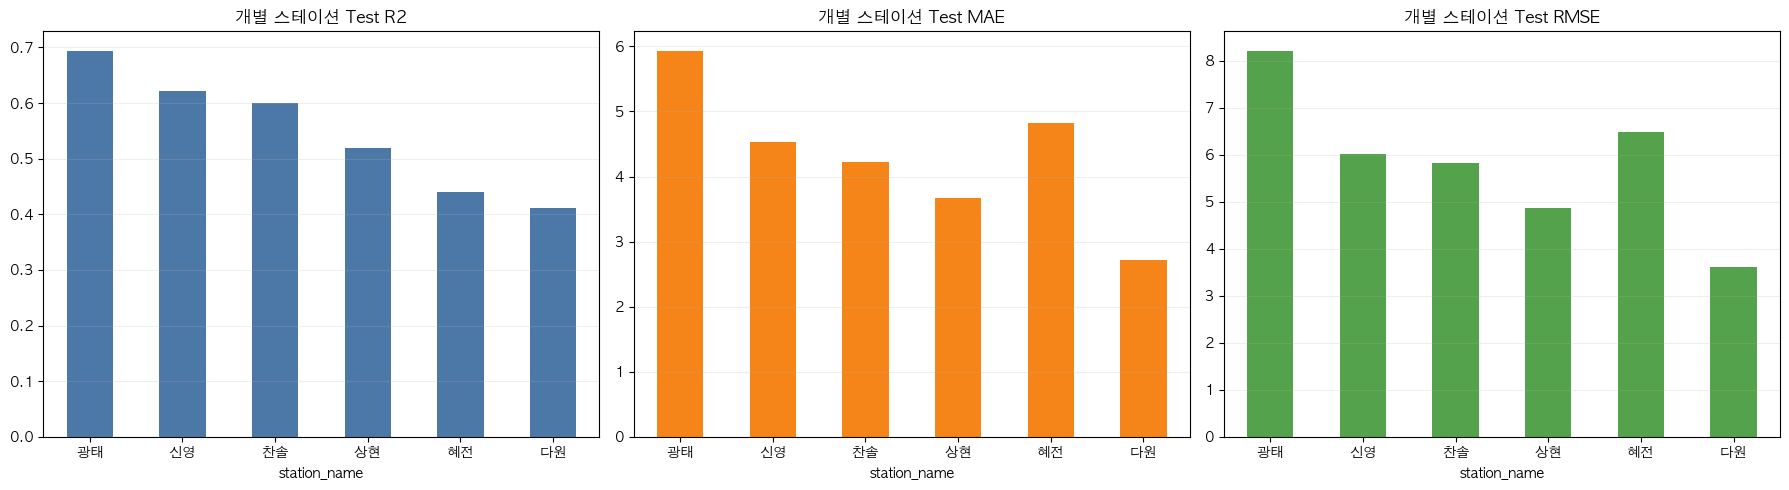

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_df = station_model_results.set_index('station_name')
plot_df['test_R2'].plot(kind='bar', ax=axes[0], color='#4C78A8')
axes[0].set_title('개별 스테이션 Test R2')
axes[0].grid(axis='y', alpha=0.2)
axes[0].tick_params(axis='x', rotation=0)
plot_df['test_MAE'].plot(kind='bar', ax=axes[1], color='#F58518')
axes[1].set_title('개별 스테이션 Test MAE')
axes[1].grid(axis='y', alpha=0.2)
axes[1].tick_params(axis='x', rotation=0)
plot_df['test_RMSE'].plot(kind='bar', ax=axes[2], color='#54A24B')
axes[2].set_title('개별 스테이션 Test RMSE')
axes[2].grid(axis='y', alpha=0.2)
axes[2].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## 6개 스테이션 통합 데이터 구성

통합 모델은 6개 스테이션의 `2024 train`, `2024 valid`, `2025 test`를 각각 합친 뒤,
`station_id`를 원-핫 인코딩해서 하나의 모델로 학습합니다.


In [9]:
combined_train = pd.concat([station_datasets[s]['train'] for s in station_ids], ignore_index=True)
combined_valid = pd.concat([station_datasets[s]['valid'] for s in station_ids], ignore_index=True)
combined_test = pd.concat([station_datasets[s]['test'] for s in station_ids], ignore_index=True)
combined_feature_cols = feature_cols + static_cols + ['station_id']
X_train_combined = pd.get_dummies(combined_train[combined_feature_cols], columns=['station_id'])
X_valid_combined = pd.get_dummies(combined_valid[combined_feature_cols], columns=['station_id'])
X_test_combined = pd.get_dummies(combined_test[combined_feature_cols], columns=['station_id'])
X_valid_combined = X_valid_combined.reindex(columns=X_train_combined.columns, fill_value=0)
X_test_combined = X_test_combined.reindex(columns=X_train_combined.columns, fill_value=0)
y_train_combined = combined_train[target_col]
y_valid_combined = combined_valid[target_col]
y_test_combined = combined_test[target_col]
print('combined_train:', X_train_combined.shape)
print('combined_valid:', X_valid_combined.shape)
print('combined_test:', X_test_combined.shape)


combined_train: (36887, 23)
combined_valid: (15814, 23)
combined_test: (51405, 23)


## 6개 스테이션 통합 RandomForest 학습 및 점수

통합 모델도 같은 파라미터 탐색 범위를 사용합니다.
최종적으로:
- 통합 전체 점수
- 통합 모델의 스테이션별 테스트 점수
를 같이 확인합니다.


In [10]:
combined_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=1),
    param_grid=rf_param_grid,
    scoring='r2',
    cv=search_cv,
    n_jobs=1,
)
combined_search.fit(X_train_combined, y_train_combined)
combined_best_model = combined_search.best_estimator_
combined_pred_train = combined_best_model.predict(X_train_combined)
combined_pred_valid = combined_best_model.predict(X_valid_combined)
combined_pred_test = combined_best_model.predict(X_test_combined)
combined_scores = pd.DataFrame([{
    'scope': '6개 통합',
    'best_params': str(combined_search.best_params_),
    'train_R2': r2_score(y_train_combined, combined_pred_train),
    'valid_R2': r2_score(y_valid_combined, combined_pred_valid),
    'test_R2': r2_score(y_test_combined, combined_pred_test),
    'train_MAE': mean_absolute_error(y_train_combined, combined_pred_train),
    'valid_MAE': mean_absolute_error(y_valid_combined, combined_pred_valid),
    'test_MAE': mean_absolute_error(y_test_combined, combined_pred_test),
    'train_RMSE': mean_squared_error(y_train_combined, combined_pred_train) ** 0.5,
    'valid_RMSE': mean_squared_error(y_valid_combined, combined_pred_valid) ** 0.5,
    'test_RMSE': mean_squared_error(y_test_combined, combined_pred_test) ** 0.5,
}])
display(combined_scores.round(4))


,scope,best_params,train_R2,valid_R2,test_R2,train_MAE,valid_MAE,test_MAE,train_RMSE,valid_RMSE,test_RMSE
0,6개 통합,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",0.8641,0.6717,0.6708,2.761,4.1686,4.24,3.8898,5.7431,5.887


In [11]:
combined_test_with_pred = combined_test[['station_id', 'timestamp', target_col]].copy()
combined_test_with_pred['pred_total_flow'] = combined_pred_test
combined_station_scores = []
for station_id in station_ids:
    station_slice = combined_test_with_pred[combined_test_with_pred['station_id'] == station_id].copy()
    combined_station_scores.append({
        'station_id': station_id,
        'station_name': station_info[station_id],
        'test_R2': r2_score(station_slice[target_col], station_slice['pred_total_flow']),
        'test_MAE': mean_absolute_error(station_slice[target_col], station_slice['pred_total_flow']),
        'test_RMSE': mean_squared_error(station_slice[target_col], station_slice['pred_total_flow']) ** 0.5,
    })
combined_station_scores = pd.DataFrame(combined_station_scores).sort_values('test_R2', ascending=False).reset_index(drop=True)
display(combined_station_scores.round(4))


,station_id,station_name,test_R2,test_MAE,test_RMSE
0,ST-2264,광태,0.7035,5.8357,8.0849
1,ST-1331,찬솔,0.6284,4.0851,5.6015
2,ST-454,신영,0.6018,4.6357,6.1730
3,ST-481,상현,0.5258,3.6497,4.8227
4,ST-453,혜전,0.5114,4.5223,6.0425
5,ST-2425,다원,0.3978,2.7112,3.6497


In [12]:
print('개별 모델 vs 통합 모델 비교용 표')
compare_station_vs_combined = station_model_results[['station_id', 'station_name', 'test_R2', 'test_MAE', 'test_RMSE']].merge(
    combined_station_scores,
    on=['station_id', 'station_name'],
    suffixes=('_individual', '_combined')
)
display(compare_station_vs_combined.round(4))


개별 모델 vs 통합 모델 비교용 표


,station_id,station_name,test_R2_individual,test_MAE_individual,test_RMSE_individual,test_R2_combined,test_MAE_combined,test_RMSE_combined
0,ST-2264,광태,0.6943,5.9355,8.2102,0.7035,5.8357,8.0849
1,ST-454,신영,0.6210,4.5323,6.0223,0.6018,4.6357,6.1730
2,ST-1331,찬솔,0.5995,4.2216,5.8152,0.6284,4.0851,5.6015
3,ST-481,상현,0.5193,3.6717,4.8557,0.5258,3.6497,4.8227
4,ST-453,혜전,0.4399,4.8158,6.4699,0.5114,4.5223,6.0425
5,ST-2425,다원,0.4115,2.7214,3.6078,0.3978,2.7112,3.6497


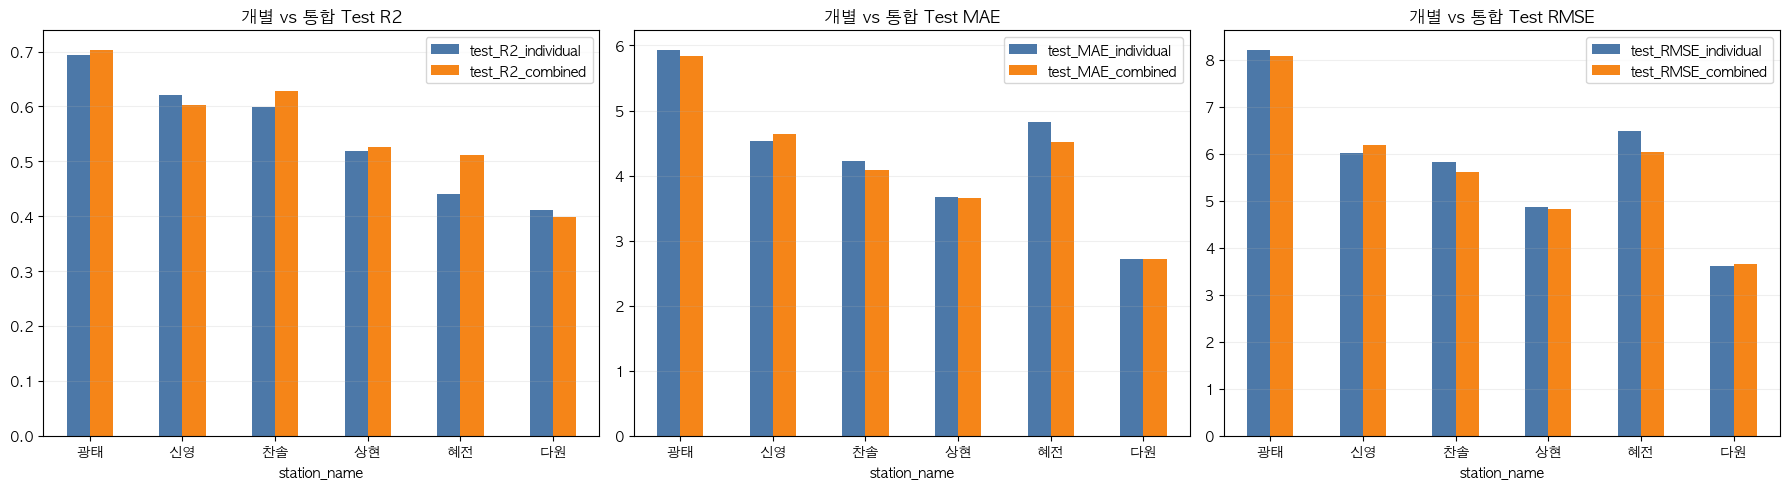

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
compare_df = compare_station_vs_combined.set_index('station_name')
compare_df[['test_R2_individual', 'test_R2_combined']].plot(kind='bar', ax=axes[0], color=['#4C78A8', '#F58518'])
axes[0].set_title('개별 vs 통합 Test R2')
axes[0].grid(axis='y', alpha=0.2)
axes[0].tick_params(axis='x', rotation=0)
compare_df[['test_MAE_individual', 'test_MAE_combined']].plot(kind='bar', ax=axes[1], color=['#4C78A8', '#F58518'])
axes[1].set_title('개별 vs 통합 Test MAE')
axes[1].grid(axis='y', alpha=0.2)
axes[1].tick_params(axis='x', rotation=0)
compare_df[['test_RMSE_individual', 'test_RMSE_combined']].plot(kind='bar', ax=axes[2], color=['#4C78A8', '#F58518'])
axes[2].set_title('개별 vs 통합 Test RMSE')
axes[2].grid(axis='y', alpha=0.2)
axes[2].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## Inflow / Outflow 통합 Baseline
이 섹션은 6개 스테이션 통합 파일에서 `inflow` 와 `outflow` 를 각각 별도 타깃으로 학습하기 위한 셀입니다.
- `inflow`: 해당 시간대 유입량
- `outflow`: 해당 시간대 유출량
- `total_flow` 와 별도로 학습해 각 방향 수요를 분리해서 확인합니다.


6개 통합 inflow / outflow 점수


,타깃,best_params,train_R2,valid_R2,test_R2,train_MAE,valid_MAE,test_MAE,train_RMSE,valid_RMSE,test_RMSE
0,유입량,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",0.8179,0.5940,0.5968,1.7495,2.6197,2.7963,2.5020,3.6082,4.0333
1,유출량,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",0.8162,0.5803,0.5137,1.8312,2.7067,2.6771,2.5909,3.7355,3.6663


스테이션별 inflow / outflow test 점수


,타깃,station_id,station_name,test_R2,test_MAE,test_RMSE
0,유입량,ST-481,상현,0.4856,2.3739,3.2099
1,유입량,ST-2425,다원,0.4330,1.6263,2.2529
2,유입량,ST-1331,찬솔,0.4859,2.8913,4.1534
3,유입량,ST-454,신영,0.5658,2.7687,3.7887
4,유입량,ST-453,혜전,0.4123,2.9516,4.1267
5,유입량,ST-2264,광태,0.6026,4.1660,5.7956
6,유출량,ST-481,상현,0.2733,2.3122,2.9879
7,유출량,ST-2425,다원,0.3781,1.8303,2.5232
8,유출량,ST-1331,찬솔,0.5349,2.5508,3.4738
9,유출량,ST-454,신영,0.3963,3.0031,3.9592


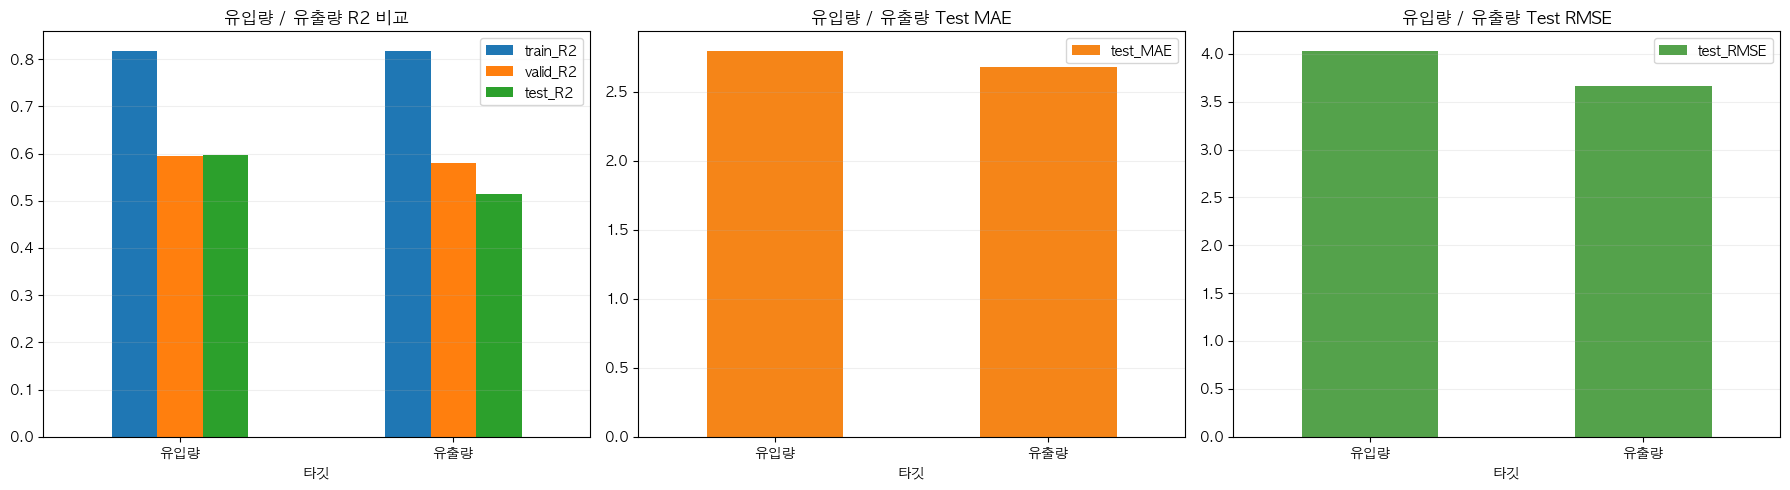

In [14]:
flow_target_results = []
flow_target_station_results = []
flow_target_artifacts = {}

for flow_target in ['inflow', 'outflow']:
    y_train_flow = combined_train[flow_target]
    y_valid_flow = combined_valid[flow_target]
    y_test_flow = combined_test[flow_target]

    flow_search = GridSearchCV(
        estimator=RandomForestRegressor(random_state=42, n_jobs=1),
        param_grid=rf_param_grid,
        scoring='r2',
        cv=search_cv,
        n_jobs=1,
    )
    flow_search.fit(X_train_combined, y_train_flow)
    flow_best_model = flow_search.best_estimator_

    flow_pred_train = flow_best_model.predict(X_train_combined)
    flow_pred_valid = flow_best_model.predict(X_valid_combined)
    flow_pred_test = flow_best_model.predict(X_test_combined)

    flow_target_artifacts[flow_target] = {
        'model': flow_best_model,
        'best_params': flow_search.best_params_,
        'pred_train': flow_pred_train,
        'pred_valid': flow_pred_valid,
        'pred_test': flow_pred_test,
    }

    flow_target_results.append({
        '타깃': flow_target,
        'best_params': str(flow_search.best_params_),
        'train_R2': r2_score(y_train_flow, flow_pred_train),
        'valid_R2': r2_score(y_valid_flow, flow_pred_valid),
        'test_R2': r2_score(y_test_flow, flow_pred_test),
        'train_MAE': mean_absolute_error(y_train_flow, flow_pred_train),
        'valid_MAE': mean_absolute_error(y_valid_flow, flow_pred_valid),
        'test_MAE': mean_absolute_error(y_test_flow, flow_pred_test),
        'train_RMSE': mean_squared_error(y_train_flow, flow_pred_train) ** 0.5,
        'valid_RMSE': mean_squared_error(y_valid_flow, flow_pred_valid) ** 0.5,
        'test_RMSE': mean_squared_error(y_test_flow, flow_pred_test) ** 0.5,
    })

    combined_test_flow = combined_test[['station_id', 'timestamp', flow_target]].copy()
    combined_test_flow['pred_value'] = flow_pred_test
    for station_id in station_ids:
        station_slice = combined_test_flow[combined_test_flow['station_id'] == station_id].copy()
        flow_target_station_results.append({
            '타깃': flow_target,
            'station_id': station_id,
            'station_name': station_info[station_id],
            'test_R2': r2_score(station_slice[flow_target], station_slice['pred_value']),
            'test_MAE': mean_absolute_error(station_slice[flow_target], station_slice['pred_value']),
            'test_RMSE': mean_squared_error(station_slice[flow_target], station_slice['pred_value']) ** 0.5,
        })

flow_target_results = pd.DataFrame(flow_target_results)
flow_target_results['타깃'] = flow_target_results['타깃'].replace({'inflow': '유입량', 'outflow': '유출량'})
print('6개 통합 inflow / outflow 점수')
display(flow_target_results.round(4))

flow_target_station_results = pd.DataFrame(flow_target_station_results)
flow_target_station_results['타깃'] = flow_target_station_results['타깃'].replace({'inflow': '유입량', 'outflow': '유출량'})
print('스테이션별 inflow / outflow test 점수')
display(flow_target_station_results.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_flow = flow_target_results.set_index('타깃')
plot_flow[['train_R2', 'valid_R2', 'test_R2']].plot(kind='bar', ax=axes[0])
axes[0].set_title('유입량 / 유출량 R2 비교')
axes[0].grid(axis='y', alpha=0.2)
axes[0].tick_params(axis='x', rotation=0)

plot_flow[['test_MAE']].plot(kind='bar', ax=axes[1], color='#F58518')
axes[1].set_title('유입량 / 유출량 Test MAE')
axes[1].grid(axis='y', alpha=0.2)
axes[1].tick_params(axis='x', rotation=0)

plot_flow[['test_RMSE']].plot(kind='bar', ax=axes[2], color='#54A24B')
axes[2].set_title('유입량 / 유출량 Test RMSE')
axes[2].grid(axis='y', alpha=0.2)
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## Net Flow 통합 Baseline
이 섹션은 6개 스테이션 통합 파일에서 `net_flow` 를 타깃으로 추가 평가하기 위한 셀입니다.
- `net_flow = inflow - outflow`
- `net_flow` 는 음수가 가능하므로 별도 타깃으로 직접 학습합니다.


In [15]:
net_target_col = 'net_flow'

y_train_net = combined_train[net_target_col]
y_valid_net = combined_valid[net_target_col]
y_test_net = combined_test[net_target_col]

net_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=1),
    param_grid=rf_param_grid,
    scoring='r2',
    cv=search_cv,
    n_jobs=1,
)
net_search.fit(X_train_combined, y_train_net)
net_best_model = net_search.best_estimator_

net_pred_train = net_best_model.predict(X_train_combined)
net_pred_valid = net_best_model.predict(X_valid_combined)
net_pred_test = net_best_model.predict(X_test_combined)

net_combined_scores = pd.DataFrame([{
    'scope': '6개 통합 net_flow',
    'best_params': str(net_search.best_params_),
    'train_R2': r2_score(y_train_net, net_pred_train),
    'valid_R2': r2_score(y_valid_net, net_pred_valid),
    'test_R2': r2_score(y_test_net, net_pred_test),
    'train_MAE': mean_absolute_error(y_train_net, net_pred_train),
    'valid_MAE': mean_absolute_error(y_valid_net, net_pred_valid),
    'test_MAE': mean_absolute_error(y_test_net, net_pred_test),
    'train_RMSE': mean_squared_error(y_train_net, net_pred_train) ** 0.5,
    'valid_RMSE': mean_squared_error(y_valid_net, net_pred_valid) ** 0.5,
    'test_RMSE': mean_squared_error(y_test_net, net_pred_test) ** 0.5,
}])
print('6개 통합 net_flow 점수')
display(net_combined_scores.round(4))

combined_test_net = combined_test[['station_id', 'timestamp', net_target_col]].copy()
combined_test_net['pred_net_flow'] = net_pred_test
net_station_scores = []
for station_id in station_ids:
    station_slice = combined_test_net[combined_test_net['station_id'] == station_id].copy()
    net_station_scores.append({
        'station_id': station_id,
        'station_name': station_info[station_id],
        'test_R2': r2_score(station_slice[net_target_col], station_slice['pred_net_flow']),
        'test_MAE': mean_absolute_error(station_slice[net_target_col], station_slice['pred_net_flow']),
        'test_RMSE': mean_squared_error(station_slice[net_target_col], station_slice['pred_net_flow']) ** 0.5,
    })
net_station_scores = pd.DataFrame(net_station_scores).sort_values('test_R2', ascending=False).reset_index(drop=True)
print('스테이션별 net_flow test 점수')
display(net_station_scores.round(4))


6개 통합 net_flow 점수


,scope,best_params,train_R2,valid_R2,test_R2,train_MAE,valid_MAE,test_MAE,train_RMSE,valid_RMSE,test_RMSE
0,6개 통합 net_flow,"{'max_depth': 8, 'min_samples_leaf': 5, 'n_est...",0.4116,0.3278,0.2107,3.0202,3.2758,3.4211,4.2331,4.502,4.9212


스테이션별 net_flow test 점수


,station_id,station_name,test_R2,test_MAE,test_RMSE
0,ST-2425,다원,0.3314,2.3177,3.2970
1,ST-453,혜전,0.3033,3.5877,5.0135
2,ST-1331,찬솔,0.1862,3.6702,5.3049
3,ST-2264,광태,0.1636,4.7430,6.7134
4,ST-481,상현,0.0617,2.7772,3.8245
5,ST-454,신영,0.0399,3.4302,4.6329


## 통합 모델 비교
이 섹션은 6개 스테이션 통합 데이터에서 `total_flow` 를 기준으로 여러 모델을 비교하기 위한 단계입니다.
- 동일한 `train / valid / test` 분할을 사용합니다.
- 기본 RandomForest 외에 선형 모델, 규제 모델, 부스팅 모델을 함께 비교합니다.
- 결과는 `R²`, `MAE`, `RMSE` 와 최적 파라미터 표로 확인합니다.


In [ ]:
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit

try:
    from xgboost import XGBRegressor
    xgb_available = True
except Exception:
    xgb_available = False

compare_target = 'total_flow'
compare_cv = TimeSeriesSplit(n_splits=3)
alpha_grid = np.logspace(-3, 3, 30)

combined_model_space = {
    'LinearRegression': {
        'estimator': make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), LinearRegression()),
        'search_type': 'none',
    },
    'RidgeCV': {
        'estimator': make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), RidgeCV(alphas=alpha_grid)),
        'search_type': 'none',
    },
    'LassoCV': {
        'estimator': make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), LassoCV(alphas=alpha_grid, max_iter=20000)),
        'search_type': 'none',
    },
    'ElasticNetCV': {
        'estimator': make_pipeline(
            SimpleImputer(strategy='median'),
            StandardScaler(),
            ElasticNetCV(alphas=alpha_grid, l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], max_iter=20000)
        ),
        'search_type': 'none',
    },
    'RandomForest': {
        'estimator': RandomForestRegressor(random_state=42, n_jobs=1),
        'search_type': 'grid',
        'param_grid': {
            'n_estimators': [200, 400],
            'max_depth': [4, 6, 8],
            'min_samples_leaf': [10, 20, 30],
            'max_features': ['sqrt', 0.8],
        },
    },
    'HGB': {
        'estimator': HistGradientBoostingRegressor(random_state=42),
        'search_type': 'grid',
        'param_grid': {
            'learning_rate': [0.03, 0.05],
            'max_iter': [200, 300],
            'max_depth': [3, 4, 5],
            'min_samples_leaf': [20, 30, 40],
            'l2_regularization': [0.0, 1.0, 3.0],
        },
    },
}

if xgb_available:
    combined_model_space['XGBoost'] = {
        'estimator': XGBRegressor(random_state=42, objective='reg:squarederror', n_jobs=1),
        'search_type': 'random',
        'param_grid': {
            'n_estimators': [150, 250, 400],
            'max_depth': [3, 4, 5],
            'learning_rate': [0.03, 0.05, 0.08],
            'subsample': [0.7, 0.8, 0.9],
            'colsample_bytree': [0.7, 0.8, 0.9],
            'min_child_weight': [3, 5, 7],
            'reg_lambda': [1.0, 3.0, 5.0],
        },
        'n_iter': 12,
    }

combined_compare_results = []
combined_compare_artifacts = {}

for model_name, config in combined_model_space.items():
    estimator = clone(config['estimator'])
    if config['search_type'] == 'none':
        fitted_model = estimator.fit(X_train_combined, y_train_combined)
        best_model = fitted_model
        if model_name == 'LinearRegression':
            best_params = {'model': 'baseline'}
        elif model_name == 'RidgeCV':
            best_params = {'alpha': float(fitted_model.named_steps['ridgecv'].alpha_)}
        elif model_name == 'LassoCV':
            best_params = {'alpha': float(fitted_model.named_steps['lassocv'].alpha_)}
        else:
            best_params = {
                'alpha': float(fitted_model.named_steps['elasticnetcv'].alpha_),
                'l1_ratio': float(fitted_model.named_steps['elasticnetcv'].l1_ratio_),
            }
    elif config['search_type'] == 'grid':
        search = GridSearchCV(
            estimator=estimator,
            param_grid=config['param_grid'],
            scoring='r2',
            cv=compare_cv,
            n_jobs=1,
        )
        search.fit(X_train_combined, y_train_combined)
        best_model = search.best_estimator_
        best_params = search.best_params_
    else:
        search = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=config['param_grid'],
            n_iter=config['n_iter'],
            scoring='r2',
            cv=compare_cv,
            n_jobs=1,
            random_state=42,
        )
        search.fit(X_train_combined, y_train_combined)
        best_model = search.best_estimator_
        best_params = search.best_params_

    pred_train = best_model.predict(X_train_combined)
    pred_valid = best_model.predict(X_valid_combined)
    pred_test = best_model.predict(X_test_combined)

    combined_compare_artifacts[model_name] = {
        'best_model': best_model,
        'best_params': best_params,
        'pred_train': pred_train,
        'pred_valid': pred_valid,
        'pred_test': pred_test,
    }

    combined_compare_results.append({
        '모델': model_name,
        'best_params': str(best_params),
        'train_R2': r2_score(y_train_combined, pred_train),
        'valid_R2': r2_score(y_valid_combined, pred_valid),
        'test_R2': r2_score(y_test_combined, pred_test),
        'train_MAE': mean_absolute_error(y_train_combined, pred_train),
        'valid_MAE': mean_absolute_error(y_valid_combined, pred_valid),
        'test_MAE': mean_absolute_error(y_test_combined, pred_test),
        'train_RMSE': mean_squared_error(y_train_combined, pred_train) ** 0.5,
        'valid_RMSE': mean_squared_error(y_valid_combined, pred_valid) ** 0.5,
        'test_RMSE': mean_squared_error(y_test_combined, pred_test) ** 0.5,
    })

combined_compare_results = pd.DataFrame(combined_compare_results).sort_values('test_R2', ascending=False).reset_index(drop=True)
combined_compare_results['train_test_gap'] = combined_compare_results['train_R2'] - combined_compare_results['test_R2']
combined_compare_results['valid_test_gap'] = combined_compare_results['valid_R2'] - combined_compare_results['test_R2']

print('통합 모델 비교 전체 표')
display(combined_compare_results.round(4))
print('모델별 최적 파라미터')
display(combined_compare_results[['모델', 'best_params']])
print('일반화 격차 확인')
display(combined_compare_results[['모델', 'train_R2', 'valid_R2', 'test_R2', 'train_test_gap', 'valid_test_gap']].round(4))

plot_df = combined_compare_results.set_index('모델')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_df[['train_R2', 'valid_R2', 'test_R2']].plot(kind='bar', ax=axes[0])
axes[0].set_title('통합 모델별 R2 비교')
axes[0].grid(axis='y', alpha=0.2)
axes[0].tick_params(axis='x', rotation=0)

plot_df[['test_MAE']].plot(kind='bar', ax=axes[1], color='#F58518')
axes[1].set_title('통합 모델별 Test MAE')
axes[1].grid(axis='y', alpha=0.2)
axes[1].tick_params(axis='x', rotation=0)

plot_df[['test_RMSE']].plot(kind='bar', ax=axes[2], color='#54A24B')
axes[2].set_title('통합 모델별 Test RMSE')
axes[2].grid(axis='y', alpha=0.2)
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
